## Read the following instructions carefully:

1. This jupyter notebook contains all the step by step instructions needed for this exercise.
1. You are free to add cells.
1. Write your functions and your answers in this jupyter notebook only.
1. Answers to theoretical questions should be written in **markdown cells (with $\LaTeX$ support)**.
1. Submit this jupyter notebook only using your ID as a filename. Not to use ZIP or RAR. For example, your Moodle submission file name should look like this (two id numbers): `123456789_987654321.ipynb`.

### Question 1 - Correlations (14 points)

Provide example datapoints matching the following descriptions. Each example should be constructed over n=50 datapoints. Provide a table description of the example data as well as a jointplot (see example below). 
If you think that the situation described is impossible then clearly explain why (you don’t need to give a rigorous proof).<br>
Pearson(x,y) = Pearson correlation<br>
τ(x,y) = Kendall rank correlation<br>
ρ(x,y) = Spearman rank correlation <br>
<img src="jointplot.png">

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.stats import pearsonr,spearmanr,kendalltau, binom, norm

#### 1.A
Data in which  $Pearson(x,y) < -0.9$ but where $n-1$ points can be selected so that for the vectors restricted to those we have $Pearson(x_{n-1},y_{n-1}) > 0.9$

Pearson(all 50)  = -0.997
Pearson(49 only) = 0.991
Is Pearson(x,y) < -0.9 ?  Yes
Is Pearson(x,y) > 0.9 when n-1 ?  Yes

Head of the data:
          x         y label
0  0.000000  0.025382  base
1  0.104167  0.184565  base
2  0.208333  0.584963  base
3  0.312500  0.042948  base
4  0.416667  0.162570  base

Summary stats:
   count      mean        std    min       25%       50%       75%         max
x   50.0  7.450000  35.032772    0.0  1.276042  2.552083  3.828125  250.000000
y   50.0 -2.493936  35.747173 -250.0  1.430175  2.465794  3.644857    5.268296


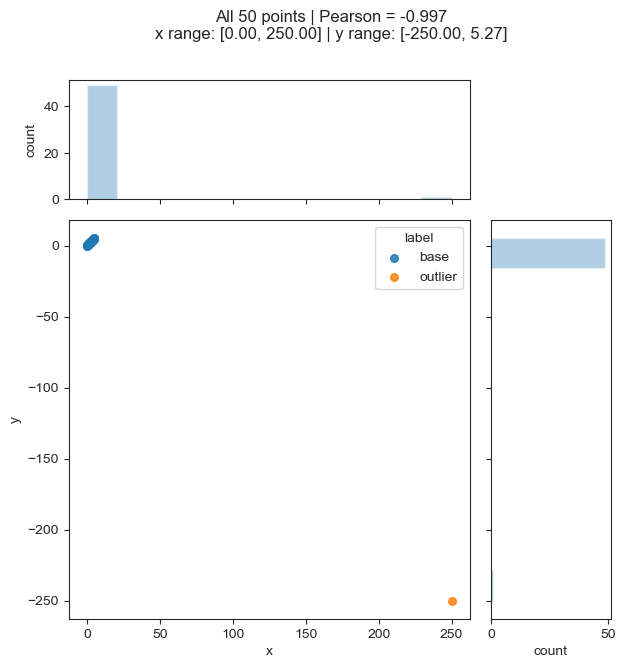

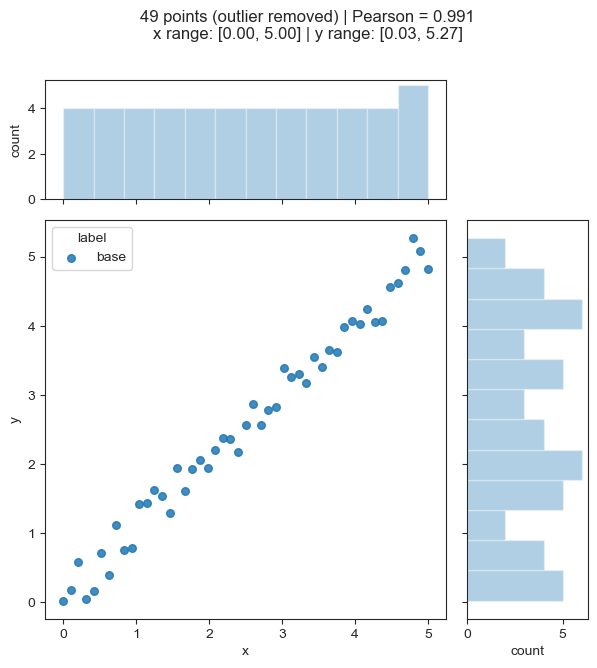

In [35]:
n = 50
n_1 = n - 1

# 1. Tighter base cluster: Reduces variance of the positive correlation relative to the outlier
x_base = np.linspace(0, 5, n_1) 
noise = np.random.normal(0, 0.2, n_1) # Reduced noise to keep base correlation > 0.9
y_base = x_base + noise

# 2. Extreme Outlier: Moves further away to dominate the global trend
# This forces the correlation to approach -1.0
x_n = np.array([250.0])
y_n = np.array([-250.0])

x = np.concatenate([x_base, x_n])
y = np.concatenate([y_base, y_n])

df = pd.DataFrame({ "x": x,
                    "y": y, 
                    "label": ["base"] * n_1 + ["outlier"]})

#Correlations
pearson_all = stats.pearsonr(df["x"], df["y"])[0]
pearson_base = stats.pearsonr(x_base, y_base)[0]
print(f"Pearson(all 50)  = {pearson_all:.3f}")
print(f"Pearson(49 only) = {pearson_base:.3f}")
print("Is Pearson(x,y) < -0.9 ? ","Yes" if pearson_all < -0.9 else "No")
print("Is Pearson(x,y) > 0.9 when n-1 ? ","Yes" if pearson_base > 0.9 else "No")

#Table Description
print("\nHead of the data:")
print(df.head())

print("\nSummary stats:")
print(df[["x", "y"]].describe().T)


def jointplot_like(df_plot, xcol="x", ycol="y", hue="label", bins=12, title=None):
    fig = plt.figure(figsize=(7, 7))
    gs = GridSpec(
        2, 2,
        width_ratios=[4, 1.2],
        height_ratios=[1.2, 4],
        wspace=0.08, hspace=0.08
    )

    ax_histx = fig.add_subplot(gs[0, 0])
    ax_scatt = fig.add_subplot(gs[1, 0])
    ax_histy = fig.add_subplot(gs[1, 1])

    #axis limits + padding
    xmin, xmax = df_plot[xcol].min(), df_plot[xcol].max()
    ymin, ymax = df_plot[ycol].min(), df_plot[ycol].max()
    xpad = 0.05 * (xmax - xmin) if xmax > xmin else 1.0
    ypad = 0.05 * (ymax - ymin) if ymax > ymin else 1.0

    ax_scatt.set_xlim(xmin - xpad, xmax + xpad)
    ax_scatt.set_ylim(ymin - ypad, ymax + ypad)

    #scatter with legend (base vs outlier)
    if hue in df_plot.columns:
        for name, sub in df_plot.groupby(hue):
            ax_scatt.scatter(sub[xcol], sub[ycol], s=30, alpha=0.85, label=str(name))
        ax_scatt.legend(frameon=True, loc="best", title=hue)
    else:
        ax_scatt.scatter(df_plot[xcol], df_plot[ycol], s=30, alpha=0.85)

    #marginals
    ax_histx.hist(df_plot[xcol], bins=bins, alpha=0.35)
    ax_histx.set_xlim(ax_scatt.get_xlim())

    ax_histy.hist(df_plot[ycol], bins=bins, orientation="horizontal", alpha=0.35)
    ax_histy.set_ylim(ax_scatt.get_ylim())

    #labels
    ax_scatt.set_xlabel(xcol)
    ax_scatt.set_ylabel(ycol)
    ax_histx.set_ylabel("count")
    ax_histy.set_xlabel("count")

    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    #title and range 
    if title is None:
        title = "Jointplot"
    title += f"\n{xcol} range: [{xmin:.2f}, {xmax:.2f}] | {ycol} range: [{ymin:.2f}, {ymax:.2f}]"
    fig.suptitle(title, y=0.98)

    plt.show()


# Jointplot: all 50 points
jointplot_like(df, title=f"All 50 points | Pearson = {pearson_all:.3f}")

# Jointplot: 49 points (outlier removed)
df_49 = df[df["label"] == "base"].copy()
jointplot_like(df_49, title=f"49 points (outlier removed) | Pearson = {pearson_base:.3f}")


#### 1.B
Data in which  $\rho(x,y) = 1$ but where $n-1$ points can be selected so that for the vectors restricted to those we have $\rho(x_{n-1},y_{n-1}) < 0.9$

Impossible. 

Spearman $\rho = 1$ implies a perfect monotonic relationship between $x$ and $y$. 

Removing a single data point from the set does not change the relative ordering of the remaining points. If we have $x_i < x_j$ it implies $y_i < y_j$ for all pairs in the original set of 50. This remains true even when removing 1 pair meaning that the relationship between the remaining points is still perfectly monotonic. 

Because the perfect monotonic relationship stays the same for any 49 points, $\rho(x_{n-1},y_{n-1})$ will still be 1 meaning that the new $\rho$ won't be inferior to 0.9.

We can conclude that the situation described is impossible.


#### 1.C
Data with τ(x,y) > ρ(x,y) + 0.45

Pearson = -0.515
Kendall = -0.020
Is Tau(x,y) superior to Rho(x,y) + 0.45 ?  True


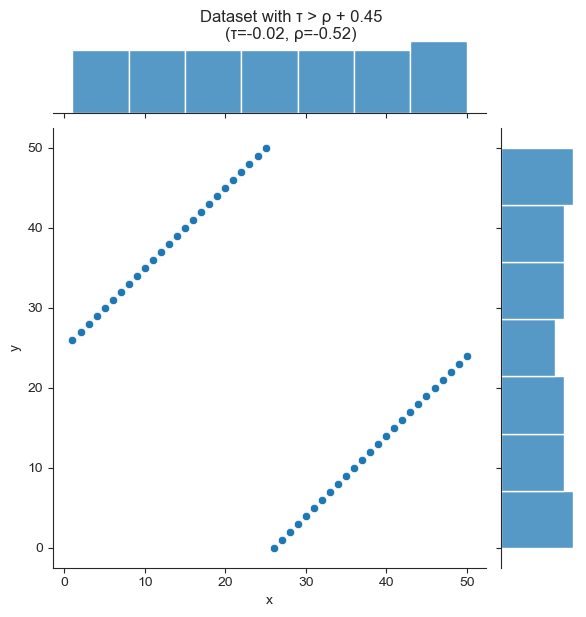

In [31]:
x = np.arange(1,51)
y1 = np.arange(26,51)
y2 = np.arange(0,25)
y = np.concatenate([y1,y2])
df = pd.DataFrame({ "x": x,
                    "y":y, 
                   })
#Correlations
pearson_all = pearsonr(df["x"], df["y"])[0]
kendall_all = kendalltau(df["x"],df["y"])[0]
print(f"Pearson = {pearson_all:.3f}")
print(f"Kendall = {kendall_all:.3f}")
sns.set_style("ticks")
g = sns.jointplot(data=df, x='x', y='y')

# Add title and labels
g.fig.suptitle(f"Dataset with τ > ρ + 0.45\n(τ={kendall_all:.2f}, ρ={pearson_all:.2f})", y=1.02)
g.set_axis_labels("x", "y")
print("Is Tau(x,y) superior to Rho(x,y) + 0.45 ? ",kendall_all > pearson_all+0.45)
plt.show()

#### 1.D
Data with τ(x,y) < ρ(x,y) – 0.45

Pearson = 0.501
Kendall = 0.020
Is Tau(x,y) inferior to Rho(x,y) - 0.45 ?  True


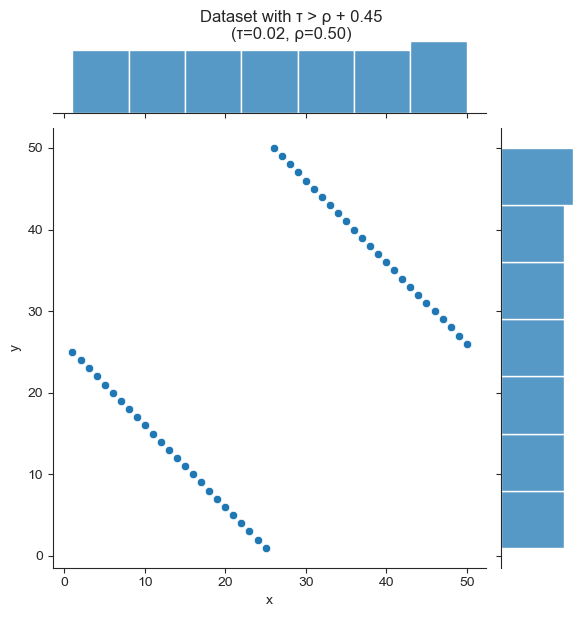

In [27]:
x = np.arange(1,51)
y1 = np.arange(25,0,-1)
y2 = np.arange(50,25,-1)
y = np.concatenate([y1,y2])
df = pd.DataFrame({ "x": x,
                    "y":y, 
                   })

#Correlations
pearson_all = pearsonr(df["x"], df["y"])[0]
kendall_all = kendalltau(df["x"],df["y"])[0]
print(f"Pearson = {pearson_all:.3f}")
print(f"Kendall = {kendall_all:.3f}")
sns.set_style("ticks")
g = sns.jointplot(data=df, x='x', y='y')

# Add title and labels
g.fig.suptitle(f"Dataset with τ > ρ + 0.45\n(τ={kendall_all:.2f}, ρ={pearson_all:.2f})", y=1.02)
g.set_axis_labels("x", "y")
print("Is Tau(x,y) inferior to Rho(x,y) - 0.45 ? ",kendall_all < pearson_all-0.45)
plt.show()

#### 1.E
Data with Pearson(x,y) < ρ(x,y) – 0.6

Spearman's Rho: 1.0000
Pearson's r:    0.2522
is Rho - 0.6 superior to pearson ? True


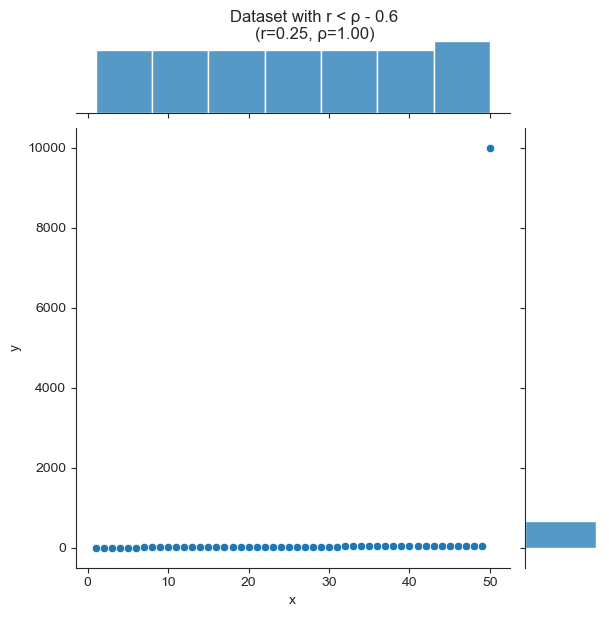

In [34]:
n = 50
x = np.arange(1, n + 1)
y = x.astype(float).copy()
y[-1] = 10_000.0  # extreme outlier: keeps ranks monotone, hurts Pearson

df = pd.DataFrame({"x": x, "y": y})
df = pd.DataFrame({'x': x, 'y': y})

rho, _ = spearmanr(df['x'], df['y'])
pearson, _ = pearsonr(df['x'], df['y'])

print(f"Spearman's Rho: {rho:.4f}")
print(f"Pearson's r:    {pearson:.4f}")
print(f"is Rho - 0.6 superior to pearson ?",rho-0.6> pearson)

sns.set_style("ticks")
g = sns.jointplot(data=df, x='x', y='y')
g.fig.suptitle(f"Dataset with r < ρ - 0.6\n(r={pearson:.2f}, ρ={rho:.2f})", y=1.02)
plt.show()

#### 1.F
Data with Pearson(x,y) > ρ(x,y) + 1.2

Pearson's r:  1.0000
Spearman's ρ: -0.7694
Is pearson superior to rho +1.2 ? True


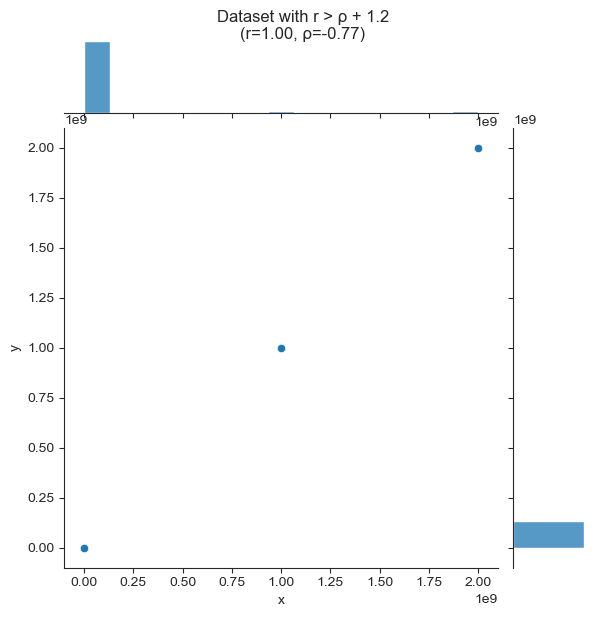

In [33]:
x1 = np.arange(1, 49, dtype=float)      # 1..48
y1 = 49 - x1                             # 48..1


x2 = np.array([1e9, 2e9], dtype=float)
y2 = np.array([1e9, 2e9], dtype=float)

x = np.concatenate([x1, x2])
y = np.concatenate([y1, y2])
df = pd.DataFrame({'x': x, 'y': y})

r, _ = pearsonr(df['x'], df['y'])
rho, _ = spearmanr(df['x'], df['y'])

print(f"Pearson's r:  {r:.4f}")
print(f"Spearman's ρ: {rho:.4f}")
print(f"Is pearson superior to rho + 1.2 ?",r > rho+1.2)

sns.set_style("ticks")
g = sns.jointplot(data=df, x='x', y='y')
g.fig.suptitle(f"Dataset with r > ρ + 1.2\n(r={r:.2f}, ρ={rho:.2f})", y=1.02)
plt.show()

#### 1.G
Data with τ(x,y) < ρ(x,y) – 1.2 

This case is Impossible. 
From our research, we found that there is a universal inequality linking $\rho$ (Spearman) and $\tau$ (Kendall) (attributed to Daniels, 1950):
$|3\tau - 2\rho| \leq 1$

From this formula we get: 
$$
3\tau - 2\rho \geq -1 \\
2\rho \leq 3\tau +1 \\
\rho - \tau \leq \frac{1 + \tau}{2} \leq 1
$$
because $\tau \leq 1$.

It means that the gap $\rho - \tau$ can never exceed 1. 
Thus, the situation where $\tau < \rho - 1.2$ is not possible since the gap would be greater than 1.

### Question 2 - Analysis of the UCI Heart Disease dataset  (38 points)

Perform data analysis on the UCI Heart Disease Dataset
References:
1. Detrano, R., Janosi, A., Steinbrunn, W., Pfisterer, M., Schmid, J., Sandhu, S., Guppy, K., Lee, S., & Froelicher, V. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. American Journal of Cardiology, 64,304--310.
2. David W. Aha & Dennis Kibler. "Instance-based prediction of heart-disease presence with the Cleveland database."
3. Gennari, J.H., Langley, P, & Fisher, D. (1989). Models of incremental concept formation. Artificial Intelligence, 40, 11--61.

Use the following links to find the details of the data: 
1. https://archive.ics.uci.edu/ml/datasets/heart+disease
2. https://www.kaggle.com/ronitf/heart-disease-uci

In the follwong cells write a report for your analysis. In your report provide a clear description of the analysis methods and of the results. This should include a graphical representation of the results and the conclusions. Provide p-values or other indicators of the statistical significance where appropriate. <br>
Design your report to be concise but still cover interesting findings.

There are missing values in the data. Find them and impute them by using the median (for numerical features) or the mode (for categorical features) value of the relevant feature (column).
Address the following questions:
* Using confidence intervals determine for which numerical features you can state with confidence of 95% that the healthy population (target = 0) mean is larger/smaller than the disease population (target = 1) mean. 
* Draw histograms for each numerical feature. Inspect the observed distributions and then use MLE to plot, on the same figures, fits of the distributions.
* For each pair of numerical feature, calculate correlations and indicate whether you find them significant. For select pairs, with significant correlations, draw joint plot with marginal histograms (see Seaborn joint plot) and find bivariate normal fits. Then use the example code below to draw plots of the bivariate pdfs (you may edit the code as you see fit).
* Are there pairs that are significantly correlated in males but not in females? The opposite? How about healthy vs disease? Can you graphically represent this?
* For each numerical feature, except age, plot the distribution for this feature against bins of age. In each bin provide a split violin plot, with different colors for healthy and disease.

Suggest, state and address at least one original question.


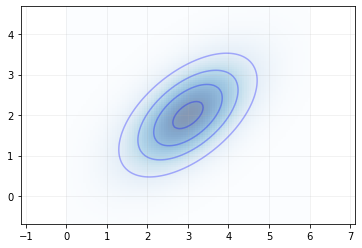

In [ ]:
# Example code for bivariate pdfs
'''from scipy.stats import multivariate_normal as mn
import numpy as np
import matplotlib.pyplot as plt'''
%matplotlib inline

def plot_2d_Gaussian_pdf(means, cov):
    n = 100
    x1 = np.linspace(means[0] - 3 * np.sqrt(cov[0][0]), means[0] + 3 * np.sqrt(cov[0][0]), n)
    x2 = np.linspace(means[1] - 3 * np.sqrt(cov[1][1]), means[1] + 3 * np.sqrt(cov[1][1]), n)
    x1_v, x2_v = np.meshgrid(x1, x2)
    Xgrid = np.vstack([x1_v.ravel(), x2_v.ravel()]).T
    Y = mn.pdf(Xgrid, means, cov)
    fig, ax = plt.subplots()
    ax.pcolorfast(x1, x2, Y.reshape(x1_v.shape), alpha=0.5, cmap='Blues')
    ax.contour(x1_v, x2_v, Y.reshape(x1_v.shape),
               levels=[0.05, 0.1, 0.15, 0.2], alpha=0.3, colors='b')
    ax.axis('equal')
    ax.grid(alpha=0.2)
    plt.show()
    
means = [3, 2]
cov = [[1, 0.5], [0.5, 0.8]]
plot_2d_Gaussian_pdf(means, cov)

In [1]:
# Question 2 - Analysis of the UCI Heart Disease Dataset
# =======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, expon, gamma, lognorm, multivariate_normal as mn
from scipy.stats import pearsonr, spearmanr, kendalltau
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# Load the dataset from local heart.csv file
# The file uses tab separators and has empty strings as missing values
df = pd.read_csv('heart.csv', sep='\t', na_values='')

print("=" * 60)
print("UCI HEART DISEASE DATASET ANALYSIS (from heart.csv)")
print("=" * 60)
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nFirst few rows:\n{df.head()}")

# Check for missing values
print(f"\nMissing values per column:\n{df.isnull().sum()}")
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

UCI HEART DISEASE DATASET ANALYSIS (from heart.csv)

Dataset shape: (303, 14)

Column types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

First few rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  3.0     145.0  233.0  1.0      0.0    150.0      0      2.3   
1  37.0  1.0  NaN     130.0  250.0  0.0      1.0    187.0      0      3.5   
2  41.0  0.0  1.0       NaN    NaN  0.0      0.0    172.0      0      1.4   
3   NaN  1.0  1.0     120.0  236.0  0.0      1.0    178.0      0      0.8   
4   NaN  0.0  0.0     120.0  354.0  0.0      1.0    163.0      1      0.6   

   slope  ca  thal  target  
0      0   0     1       1  
1      0   0     2       1  
2      2   0     2       1  
3      2   0     

In [2]:
# Data Preprocessing: Handle Missing Values
# ==========================================

# Define numerical and categorical features
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Convert target to binary (0 = healthy, 1 = disease)
# Original target: 0 = no disease, 1-4 = presence of disease
df['target'] = (df['target'] > 0).astype(int)

print("Missing values before imputation:")
print(df.isnull().sum())

# Impute missing values
# Numerical: median, Categorical: mode
for col in numerical_features:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Imputed {col} with median: {df[col].median()}")

for col in categorical_features:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Imputed {col} with mode: {mode_val}")

print("\nMissing values after imputation:")
print(df.isnull().sum())
print(f"\nDataset summary:\n{df.describe()}")

Missing values before imputation:
age         8
sex         4
cp          5
trestbps    6
chol        6
fbs         3
restecg     2
thalach     4
exang       0
oldpeak     5
slope       0
ca          0
thal        0
target      0
dtype: int64
Imputed age with median: 55.0
Imputed trestbps with median: 130.0
Imputed chol with median: 240.0
Imputed thalach with median: 153.0
Imputed oldpeak with median: 0.8
Imputed sex with mode: 1.0
Imputed cp with mode: 0.0
Imputed fbs with mode: 0.0
Imputed restecg with mode: 1.0

Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Dataset summary:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.405941    0.686469    0.953795  131.630363  24

In [3]:
# Part 1: Confidence Intervals - Comparing Healthy vs Disease Populations
# ========================================================================

# Split data by target
healthy = df[df['target'] == 0]
disease = df[df['target'] == 1]

print(f"Healthy population (target=0): n = {len(healthy)}")
print(f"Disease population (target=1): n = {len(disease)}")

print("\n" + "=" * 105)
print("95% CONFIDENCE INTERVALS FOR NUMERICAL FEATURES")
print("=" * 105)
print("-" * 105)
print(f"{'Feature':<10} | {'Healthy Mean (95% CI)':<25} | {'Disease Mean (95% CI)':<25} | {'Diff CI (95%)':<20} | {'Conclusion'}")
print("-" * 105)

for feature in numerical_features:
    # 1. Get Data
    h = healthy[feature]
    d = disease[feature]
    
    # 2. Individual Means & CIs
    mean_h, mean_d = h.mean(), d.mean()
    ci_h = stats.t.interval(0.95, len(h)-1, loc=mean_h, scale=stats.sem(h))
    ci_d = stats.t.interval(0.95, len(d)-1, loc=mean_d, scale=stats.sem(d))
    
    # 3. Difference CI (The key for answering the question)
    diff = mean_h - mean_d
    se_diff = np.sqrt((h.var(ddof=1)/len(h)) + (d.var(ddof=1)/len(d)))
    dof = len(h) + len(d) - 2 
    ci_diff = stats.t.interval(0.95, dof, loc=diff, scale=se_diff)
    
    # 4. Determine Significance based on Difference CI
    if ci_diff[0] > 0:
        conclusion = "Healthy > Disease"
    elif ci_diff[1] < 0:
        conclusion = "Disease > Healthy"
    else:
        conclusion = "No Diff"

    # 5. Print Row
    h_str = f"{mean_h:.1f} [{ci_h[0]:.1f}, {ci_h[1]:.1f}]"
    d_str = f"{mean_d:.1f} [{ci_d[0]:.1f}, {ci_d[1]:.1f}]"
    diff_str = f"[{ci_diff[0]:.1f}, {ci_diff[1]:.1f}]"
    
    print(f"{feature:<10} | {h_str:<25} | {d_str:<25} | {diff_str:<20} | {conclusion}")

Healthy population (target=0): n = 138
Disease population (target=1): n = 165

95% CONFIDENCE INTERVALS FOR NUMERICAL FEATURES
---------------------------------------------------------------------------------------------------------
Feature    | Healthy Mean (95% CI)     | Disease Mean (95% CI)     | Diff CI (95%)        | Conclusion
---------------------------------------------------------------------------------------------------------
age        | 56.7 [55.3, 58.0]         | 52.5 [51.1, 54.0]         | [2.2, 6.1]           | Healthy > Disease
trestbps   | 134.4 [131.2, 137.6]      | 129.3 [126.9, 131.7]      | [1.1, 9.0]           | Healthy > Disease
chol       | 250.6 [242.3, 258.9]      | 241.9 [233.7, 250.1]      | [-2.9, 20.3]         | No Diff
thalach    | 139.1 [135.3, 142.9]      | 158.4 [155.5, 161.4]      | [-24.1, -14.6]       | Disease > Healthy
oldpeak    | 1.6 [1.4, 1.8]            | 0.6 [0.5, 0.7]            | [0.7, 1.2]           | Healthy > Disease


HISTOGRAMS WITH MLE DISTRIBUTION FITS


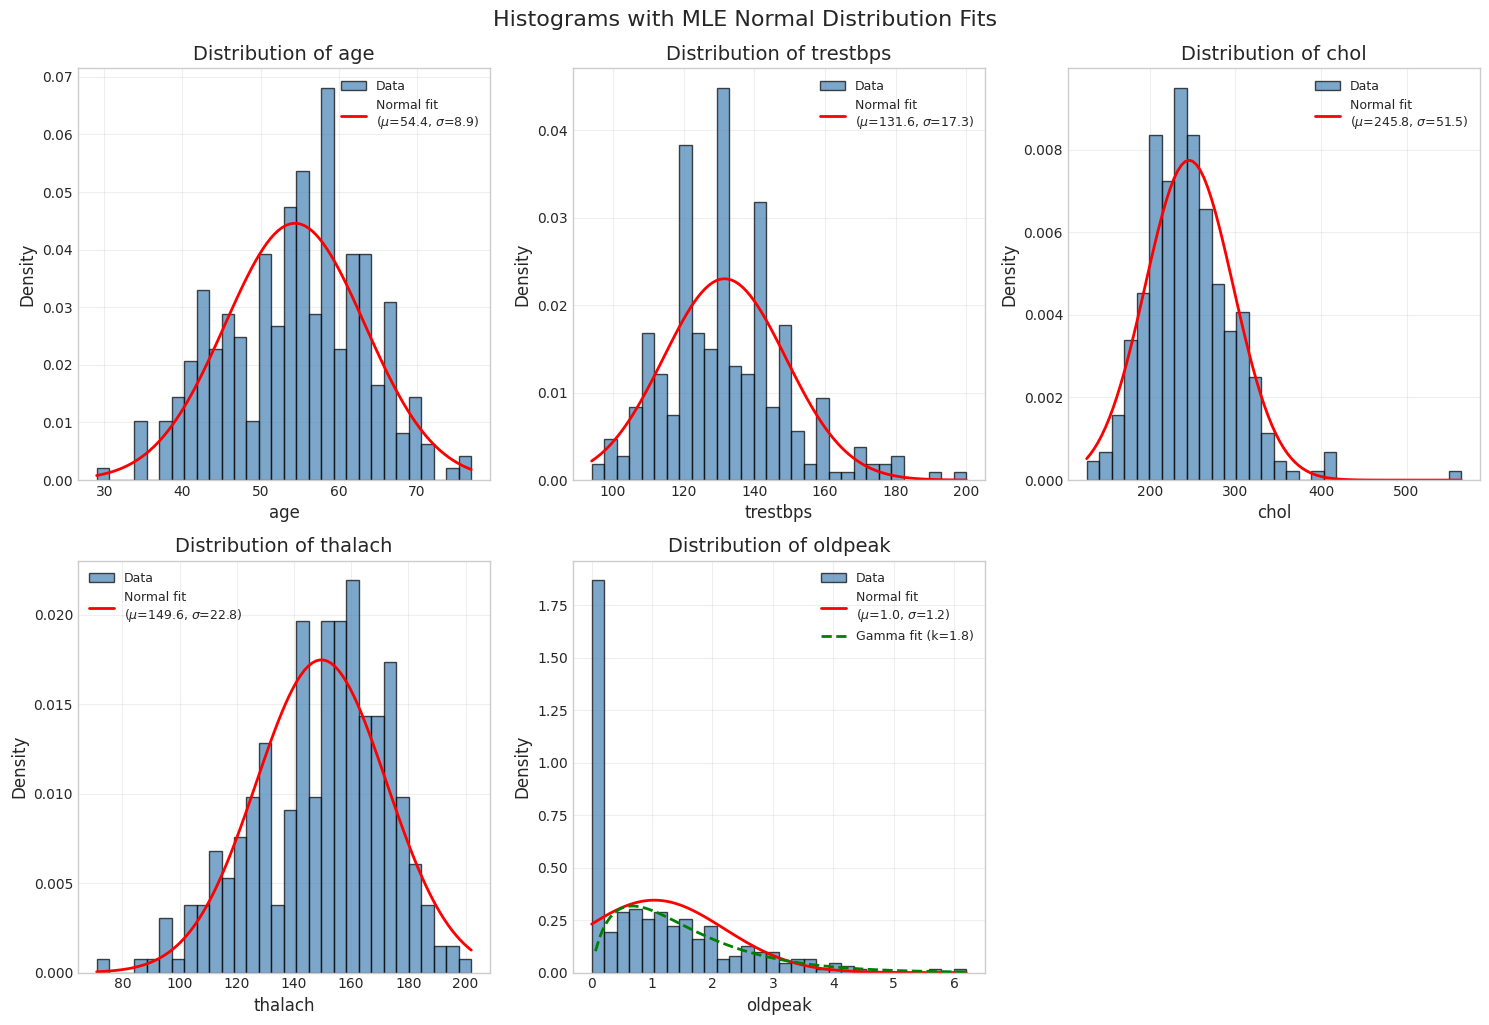


MLE Parameters for Normal Fits:
----------------------------------------
age: mu = 54.41, sigma = 8.95
trestbps: mu = 131.63, sigma = 17.33
chol: mu = 245.85, sigma = 51.52
thalach: mu = 149.61, sigma = 22.82
oldpeak: mu = 1.04, sigma = 1.16


In [4]:
# Part 2: Histograms with MLE Distribution Fits
# ==============================================

print("=" * 60)
print("HISTOGRAMS WITH MLE DISTRIBUTION FITS")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    ax = axes[idx]
    data = df[feature].values
    
    # Plot histogram
    ax.hist(data, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black', label='Data')
    
    # Fit Normal distribution using MLE
    mu, std = norm.fit(data)
    x = np.linspace(data.min(), data.max(), 100)
    pdf_norm = norm.pdf(x, mu, std)
    ax.plot(x, pdf_norm, 'r-', lw=2, label=f'Normal fit\n($\mu$={mu:.1f}, $\sigma$={std:.1f})')
    
    # For oldpeak (has many zeros), also try exponential
    if feature == 'oldpeak':
        # Shift data for gamma fit (avoid zero issues)
        data_shifted = data[data > 0]
        if len(data_shifted) > 10:
            shape, loc, scale = gamma.fit(data_shifted, floc=0)
            pdf_gamma = gamma.pdf(x[x > 0], shape, loc=0, scale=scale)
            ax.plot(x[x > 0], pdf_gamma * (len(data_shifted)/len(data)), 'g--', lw=2, 
                   label=f'Gamma fit (k={shape:.1f})')
    
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'Distribution of {feature}', fontsize=14)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Remove empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.suptitle('Histograms with MLE Normal Distribution Fits', fontsize=16, y=1.02)
plt.show()

print("\nMLE Parameters for Normal Fits:")
print("-" * 40)
for feature in numerical_features:
    mu, std = norm.fit(df[feature])
    print(f"{feature}: mu = {mu:.2f}, sigma = {std:.2f}")

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import pearsonr, spearmanr, kendalltau

# Helper function to check significance
def check_sig(p_val, alpha=0.05):
    return "Yes" if p_val < alpha else "No"

# Helper function to format p-value smartly
# Uses scientific notation only for very small numbers (< 0.0001)
# otherwise uses 4 decimal places to show values like 0.0018 clearly.
def format_p(p):
    if p < 0.0001:
        return f"{p:.2e}"
    else:
        return f"{p:.4f}"

print(f"{'Pair':<30} {'Metric':<10} {'Coeff':<10} {'P-Value':<15} {'Significant?'}")
print("-" * 90)

for n_f1, n_f2 in combinations(numerical_features, 2):
    # Pearson
    p_corr, p_p = pearsonr(df[n_f1], df[n_f2])
    print(f"{n_f1} - {n_f2:<20} {'Pearson':<10} {p_corr:.4f}     {format_p(p_p):<15} {check_sig(p_p)}")

    # Spearman
    s_corr, s_p = spearmanr(df[n_f1], df[n_f2])
    print(f"{'' :<30} {'Spearman':<10} {s_corr:.4f}     {format_p(s_p):<15} {check_sig(s_p)}")

    # Kendall
    k_corr, k_p = kendalltau(df[n_f1], df[n_f2])
    print(f"{'' :<30} {'Kendall':<10} {k_corr:.4f}     {format_p(k_p):<15} {check_sig(k_p)}")
    print("-" * 90)

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Pearson Heatmap
sns.heatmap(df[numerical_features].corr(method='pearson'), annot=True, cmap='coolwarm', ax=axes[0], fmt=".4f")
axes[0].set_title('Pearson Correlation')

# Spearman Heatmap
sns.heatmap(df[numerical_features].corr(method='spearman'), annot=True, cmap='coolwarm', ax=axes[1], fmt=".4f")
axes[1].set_title('Spearman Correlation')

# Kendall Heatmap
sns.heatmap(df[numerical_features].corr(method='kendall'), annot=True, cmap='coolwarm', ax=axes[2], fmt=".4f")
axes[2].set_title('Kendall Correlation')

plt.tight_layout()
plt.show()


Correlation between age and trestbps:
Pearson correlation coefficient: 0.25679423263044077, p-value:  0.000
Spearman correlation coefficient: 0.2605957148412386, p-value:  0.000
Kendall correlation coefficient: 0.1838115983599489, p-value:  0.000

Correlation between age and chol:
Pearson correlation coefficient: 0.20890859159075753, p-value:  0.000
Spearman correlation coefficient: 0.18858595370234046, p-value:  0.001
Kendall correlation coefficient: 0.13018970815641648, p-value:  0.001

Correlation between age and thalach:
Pearson correlation coefficient: -0.4016712445609852, p-value:  0.000
Spearman correlation coefficient: -0.40397100260048757, p-value:  0.000
Kendall correlation coefficient: -0.28367903656004106, p-value:  0.000

Correlation between age and oldpeak:
Pearson correlation coefficient: 0.21847710612643478, p-value:  0.000
Spearman correlation coefficient: 0.28264044554197887, p-value:  0.000
Kendall correlation coefficient: 0.20475391646894245, p-value:  0.000

Corre

### The features that are most significantly correlated includes the following:
* **age** and **thalach**
* **oldpeak** and **thalach**
* **oldpeak** and **age**

JOINT PLOTS WITH BIVARIATE NORMAL FITS


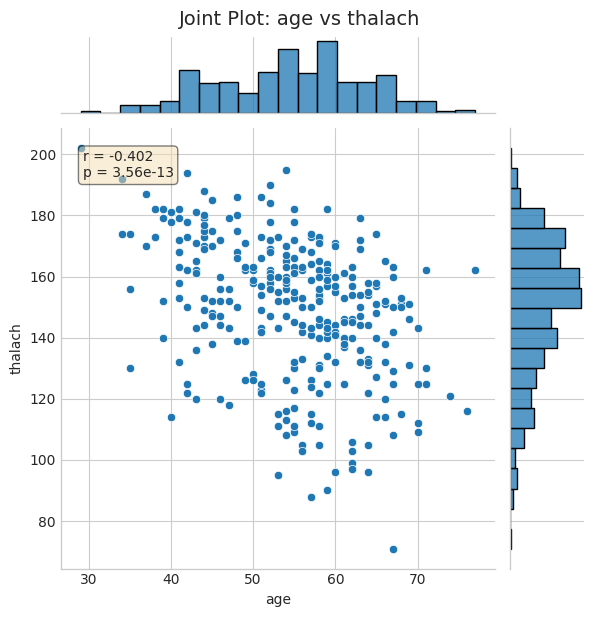


age vs thalach:
  Means: [ 54.40594059 149.61056106]
  Covariance matrix:
[[ 80.35453413 -82.30496361]
 [-82.30496361 522.51670929]]


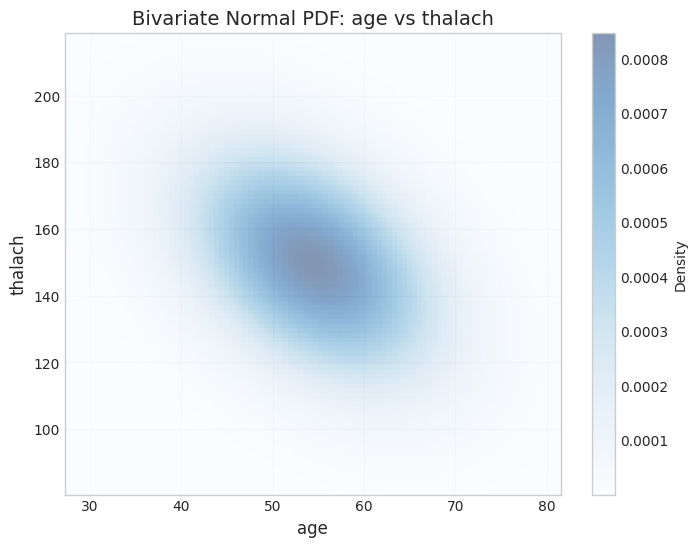

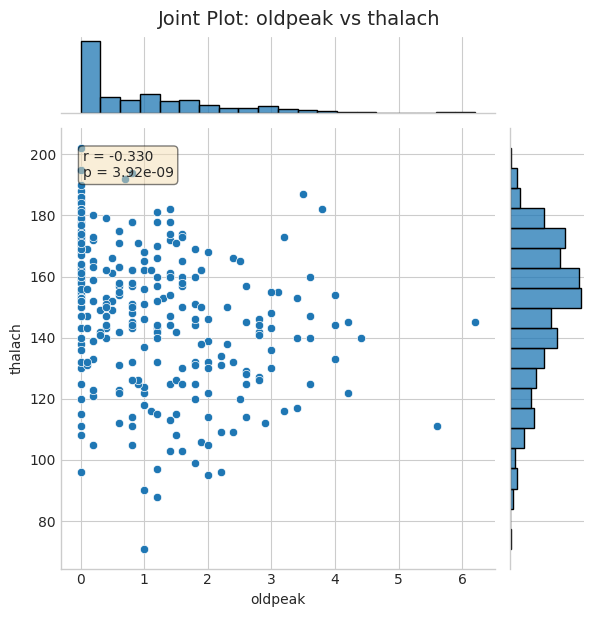


oldpeak vs thalach:
  Means: [  1.03663366 149.61056106]
  Covariance matrix:
[[  1.34133565  -8.73800407]
 [ -8.73800407 522.51670929]]


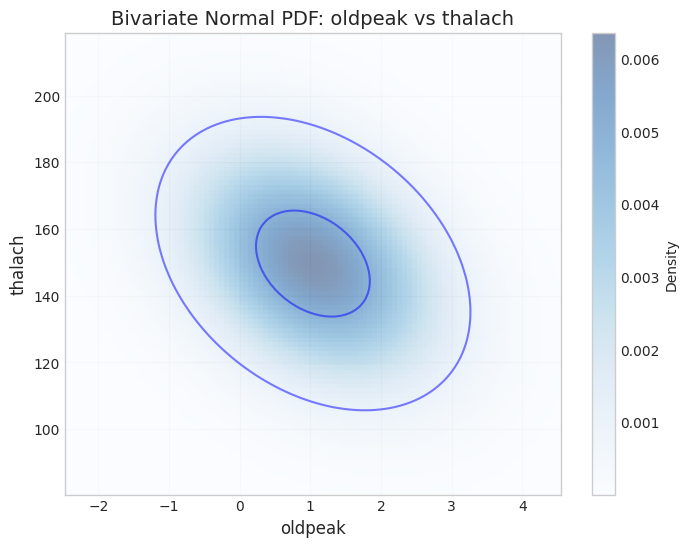

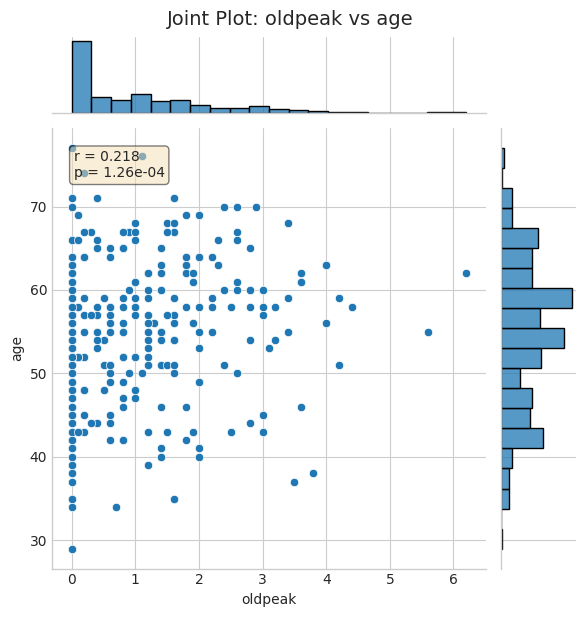


oldpeak vs age:
  Means: [ 1.03663366 54.40594059]
  Covariance matrix:
[[ 1.34133565  2.26819225]
 [ 2.26819225 80.35453413]]


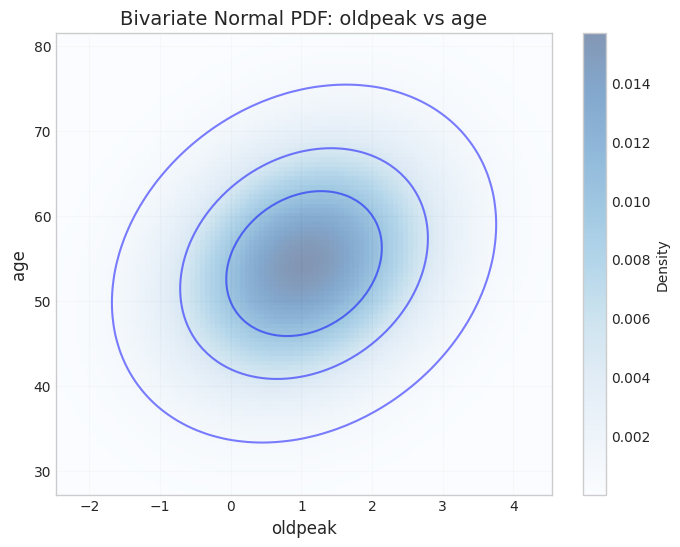

In [14]:
# Part 3b: Joint Plots with Bivariate Normal Fits for Significant Correlations
# =============================================================================

print("=" * 60)
print("JOINT PLOTS WITH BIVARIATE NORMAL FITS")
print("=" * 60)

# Select top significant pairs for visualization
top_pairs = [('age', 'thalach'), ('oldpeak', 'thalach'), ('oldpeak', 'age')]

for f1, f2 in top_pairs:
    # Create joint plot
    g = sns.jointplot(data=df, x=f1, y=f2, kind='scatter', 
                     marginal_kws={'bins': 20}, height=6)
    g.fig.suptitle(f'Joint Plot: {f1} vs {f2}', y=1.02, fontsize=14)
    
    # Calculate correlation
    r, p = pearsonr(df[f1], df[f2])
    g.ax_joint.annotate(f'r = {r:.3f}\np = {p:.2e}', 
                        xy=(0.05, 0.95), xycoords='axes fraction',
                        fontsize=10, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.show()
    
    # Bivariate normal fit
    data_pair = df[[f1, f2]].values
    means = np.mean(data_pair, axis=0)
    cov = np.cov(data_pair.T)
    
    print(f"\n{f1} vs {f2}:")
    print(f"  Means: {means}")
    print(f"  Covariance matrix:\n{cov}")
    
    # Plot bivariate PDF
    def plot_2d_Gaussian_pdf_custom(means, cov, f1_name, f2_name):
        n = 100
        x1 = np.linspace(means[0] - 3 * np.sqrt(cov[0][0]), means[0] + 3 * np.sqrt(cov[0][0]), n)
        x2 = np.linspace(means[1] - 3 * np.sqrt(cov[1][1]), means[1] + 3 * np.sqrt(cov[1][1]), n)
        x1_v, x2_v = np.meshgrid(x1, x2)
        Xgrid = np.vstack([x1_v.ravel(), x2_v.ravel()]).T
        Y = mn.pdf(Xgrid, means, cov)
        fig, ax = plt.subplots(figsize=(8, 6))
        pcm = ax.pcolormesh(x1, x2, Y.reshape(x1_v.shape), alpha=0.5, cmap='Blues', shading='auto')
        ax.contour(x1_v, x2_v, Y.reshape(x1_v.shape),
                   levels=[0.001, 0.005, 0.01, 0.02], alpha=0.5, colors='b')
        ax.set_xlabel(f1_name, fontsize=12)
        ax.set_ylabel(f2_name, fontsize=12)
        ax.set_title(f'Bivariate Normal PDF: {f1_name} vs {f2_name}', fontsize=14)
        ax.grid(alpha=0.2)
        plt.colorbar(pcm, ax=ax, label='Density')
        plt.show()
    
    plot_2d_Gaussian_pdf_custom(means, cov, f1, f2)

CORRELATION COMPARISON: MALES vs FEMALES, HEALTHY vs DISEASE

Males: n = 208
Females: n = 95

------------------------------------------------------------
Males vs Females Correlation Comparison
------------------------------------------------------------
           Features    Male r       Male p  Female r  Female p                 Difference
    age vs trestbps  0.244689 3.680529e-04  0.268502  0.008516        Significant in both
        age vs chol  0.168917 1.472675e-02  0.240547  0.018869        Significant in both
     age vs thalach -0.414002 5.100029e-10 -0.399214  0.000061        Significant in both
     age vs oldpeak  0.227949 9.282521e-04  0.230982  0.024317        Significant in both
   trestbps vs chol  0.088737 2.024557e-01  0.129123  0.212358  Not significant in either
trestbps vs thalach -0.022189 7.503900e-01 -0.093803  0.365904  Not significant in either
trestbps vs oldpeak  0.108667 1.181918e-01  0.389482  0.000096 Significant in Female only
    chol vs thalach -0.0

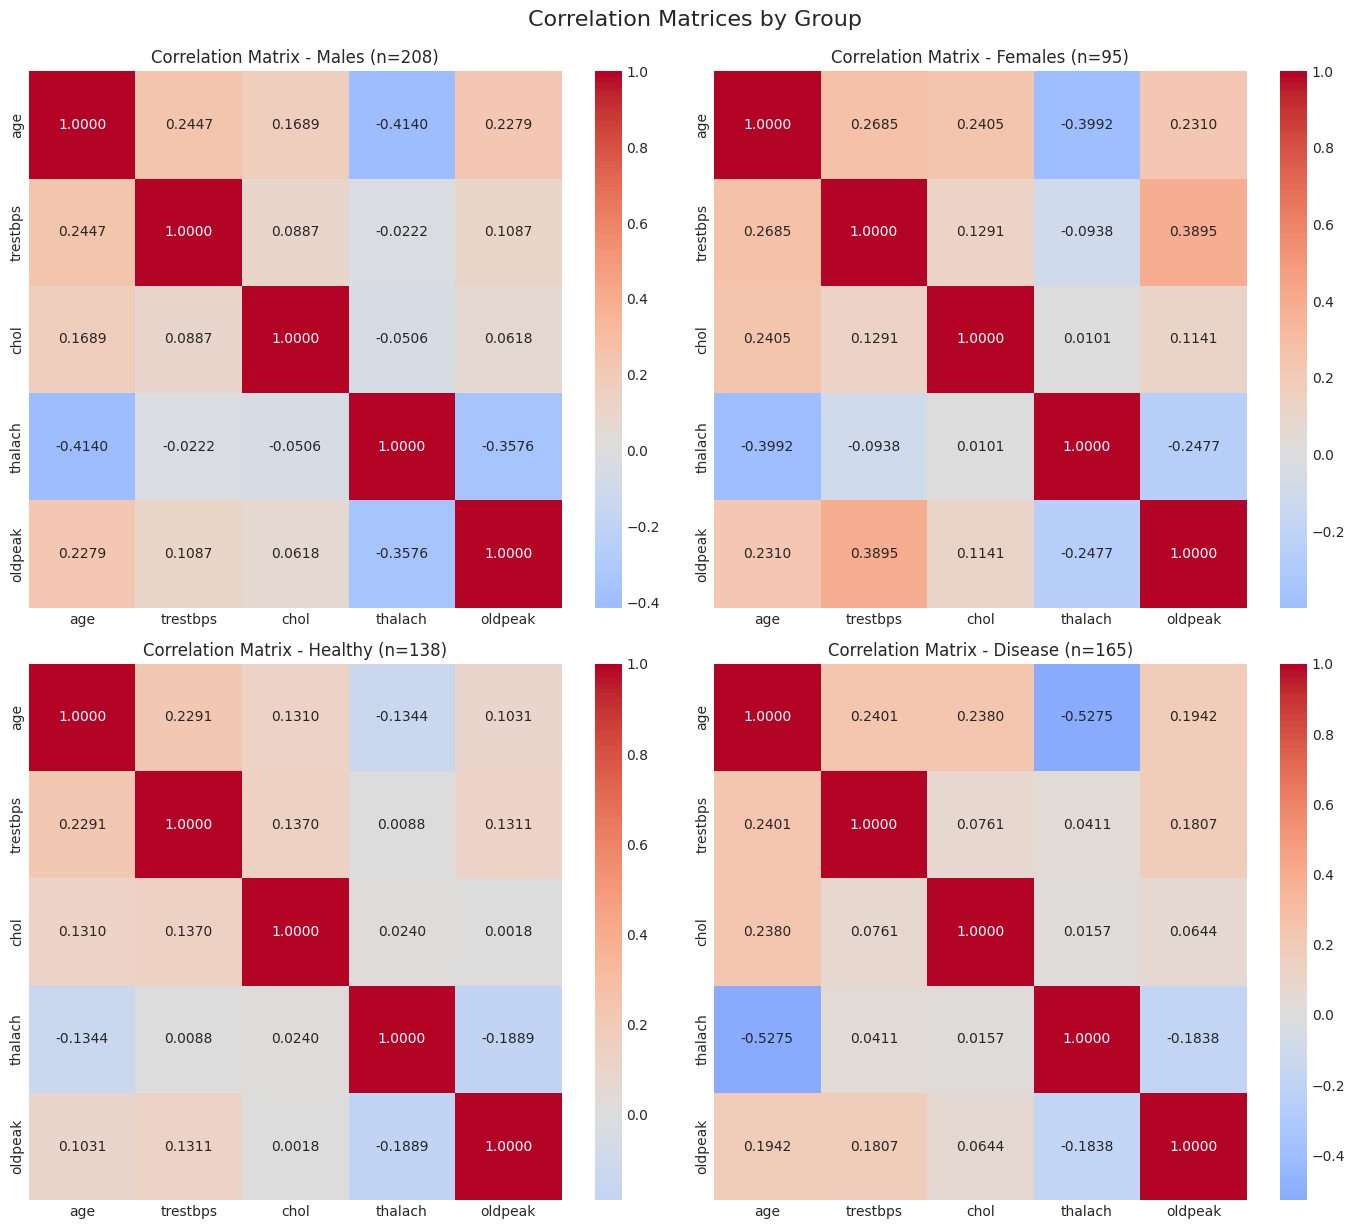

In [21]:
# Part 4: Correlation Comparison - Males vs Females, Healthy vs Disease
# ======================================================================

print("=" * 60)
print("CORRELATION COMPARISON: MALES vs FEMALES, HEALTHY vs DISEASE")
print("=" * 60)

# Split data
males = df[df['sex'] == 1]
females = df[df['sex'] == 0]

print(f"\nMales: n = {len(males)}")
print(f"Females: n = {len(females)}")

def compare_correlations(group1, group2, group1_name, group2_name, features):
    """Compare correlations between two groups."""
    results = []
    for f1, f2 in combinations(features, 2):
        r1, p1 = pearsonr(group1[f1], group1[f2])
        r2, p2 = pearsonr(group2[f1], group2[f2])
        
        sig1 = p1 < 0.05
        sig2 = p2 < 0.05
        
        diff_type = ""
        if sig1 and not sig2:
            diff_type = f"Significant in {group1_name} only"
        elif sig2 and not sig1:
            diff_type = f"Significant in {group2_name} only"
        elif sig1 and sig2:
            diff_type = "Significant in both"
        else:
            diff_type = "Not significant in either"
        
        results.append({
            'Features': f'{f1} vs {f2}',
            f'{group1_name} r': r1,
            f'{group1_name} p': p1,
            f'{group2_name} r': r2,
            f'{group2_name} p': p2,
            'Difference': diff_type
        })
    return pd.DataFrame(results)

# Compare males vs females
print("\n" + "-" * 60)
print("Males vs Females Correlation Comparison")
print("-" * 60)
male_female_comp = compare_correlations(males, females, 'Male', 'Female', numerical_features)
print(male_female_comp.to_string(index=False))

# Compare healthy vs disease
print("\n" + "-" * 60)
print("Healthy vs Disease Correlation Comparison")
print("-" * 60)
health_comp = compare_correlations(healthy, disease, 'Healthy', 'Disease', numerical_features)
print(health_comp.to_string(index=False))

# Find pairs with different significance
print("\n" + "=" * 60)
print("INTERESTING FINDINGS")
print("=" * 60)

male_only = male_female_comp[male_female_comp['Difference'] == 'Significant in Male only']
female_only = male_female_comp[male_female_comp['Difference'] == 'Significant in Female only']

print(f"\nPairs significant in MALES only: {len(male_only)}")
if len(male_only) > 0:
    print(male_only[['Features', 'Male r', 'Male p', 'Female r', 'Female p']].to_string(index=False))

print(f"\nPairs significant in FEMALES only: {len(female_only)}")
if len(female_only) > 0:
    print(female_only[['Features', 'Male r', 'Male p', 'Female r', 'Female p']].to_string(index=False))

# Graphical representation
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Males correlation matrix
corr_male = males[numerical_features].corr()
sns.heatmap(corr_male, annot=True, cmap='coolwarm', center=0, ax=axes[0, 0], fmt='.4f')
axes[0, 0].set_title(f'Correlation Matrix - Males (n={len(males)})', fontsize=12)

# Females correlation matrix
corr_female = females[numerical_features].corr()
sns.heatmap(corr_female, annot=True, cmap='coolwarm', center=0, ax=axes[0, 1], fmt='.4f')
axes[0, 1].set_title(f'Correlation Matrix - Females (n={len(females)})', fontsize=12)

# Healthy correlation matrix
corr_healthy = healthy[numerical_features].corr()
sns.heatmap(corr_healthy, annot=True, cmap='coolwarm', center=0, ax=axes[1, 0], fmt='.4f')
axes[1, 0].set_title(f'Correlation Matrix - Healthy (n={len(healthy)})', fontsize=12)

# Disease correlation matrix
corr_disease = disease[numerical_features].corr()
sns.heatmap(corr_disease, annot=True, cmap='coolwarm', center=0, ax=axes[1, 1], fmt='.4f')
axes[1, 1].set_title(f'Correlation Matrix - Disease (n={len(disease)})', fontsize=12)

plt.tight_layout()
plt.suptitle('Correlation Matrices by Group', fontsize=16, y=1.02)
plt.show()

SPLIT VIOLIN PLOTS: FEATURES BY AGE BINS (HEALTHY vs DISEASE)


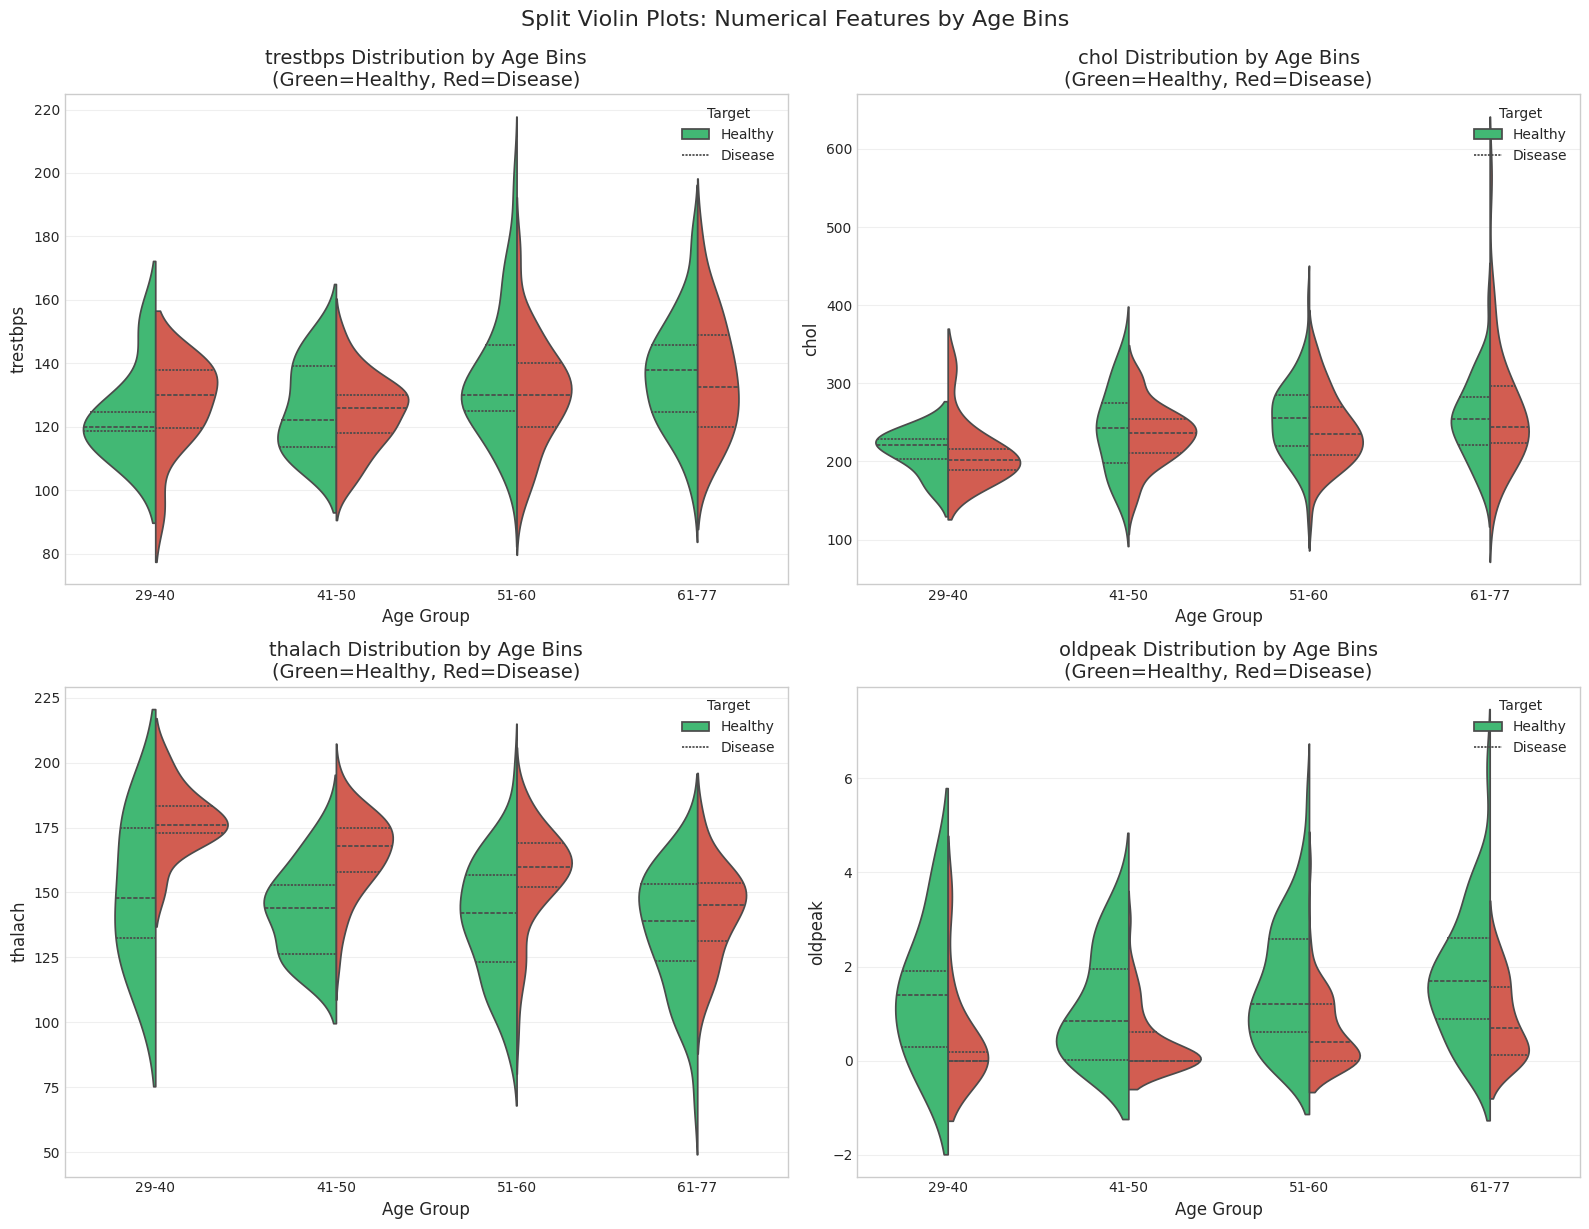


Statistics by Age Bin and Health Status:
------------------------------------------------------------

TRESTBPS:
                      mean        std  count
age_bin target                              
29-40   0       124.333333  14.500575      6
        1       127.166667  13.630403     12
41-50   0       126.272727  13.915328     22
        1       124.283019  11.514836     53
51-60   0       136.575758  20.541186     66
        1       130.393939  16.584403     66
61-77   0       136.568182  17.345193     44
        1       135.823529  18.477621     34

CHOL:
                      mean        std  count
age_bin target                              
29-40   0       213.000000  26.570661      6
        1       211.833333  40.273685     12
41-50   0       240.818182  53.102449     22
        1       234.471698  37.437951     53
51-60   0       254.469697  48.059969     66
        1       240.984848  46.071013     66
61-77   0       254.727273  50.313142     44
        1       265.8529

In [22]:
# Part 5: Split Violin Plots by Age Bins
# =======================================

print("=" * 60)
print("SPLIT VIOLIN PLOTS: FEATURES BY AGE BINS (HEALTHY vs DISEASE)")
print("=" * 60)

# Create age bins
df['age_bin'] = pd.cut(df['age'], bins=[28, 40, 50, 60, 78], labels=['29-40', '41-50', '51-60', '61-77'])

# Features to plot (excluding age)
features_for_violin = ['trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(features_for_violin):
    ax = axes[idx]
    
    # Create split violin plot
    sns.violinplot(data=df, x='age_bin', y=feature, hue='target', 
                   split=True, inner='quart', palette=['#2ecc71', '#e74c3c'], ax=ax)
    
    ax.set_xlabel('Age Group', fontsize=12)
    ax.set_ylabel(feature, fontsize=12)
    ax.set_title(f'{feature} Distribution by Age Bins\n(Green=Healthy, Red=Disease)', fontsize=14)
    ax.legend(title='Target', labels=['Healthy', 'Disease'], loc='upper right')
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.suptitle('Split Violin Plots: Numerical Features by Age Bins', fontsize=16, y=1.02)
plt.show()

# Print statistics for each age bin
print("\nStatistics by Age Bin and Health Status:")
print("-" * 60)
for feature in features_for_violin:
    print(f"\n{feature.upper()}:")
    grouped = df.groupby(['age_bin', 'target'])[feature].agg(['mean', 'std', 'count'])
    print(grouped.to_string())

ORIGINAL QUESTION: COMBINED PREDICTIVE POWER OF CHEST PAIN TYPE
AND EXERCISE-INDUCED ANGINA

RESEARCH QUESTION: Does the combination of chest pain type (cp) and 
exercise-induced angina (exang) provide better discrimination between 
healthy and diseased individuals than either feature alone?


------------------------------------------------------------
Chest Pain Type Distribution by Health Status
------------------------------------------------------------
     Healthy %  Disease %
cp                       
0.0      0.717      0.283
1.0      0.180      0.820
2.0      0.212      0.788
3.0      0.304      0.696

Chi-square test for cp: chi2 = 77.83, p = 8.95e-17

------------------------------------------------------------
Exercise-Induced Angina Distribution by Health Status
------------------------------------------------------------
           Healthy %  Disease %
No Angina      0.304      0.696
Angina         0.768      0.232

Chi-square test for exang: chi2 = 55.94, p = 7.45e-14



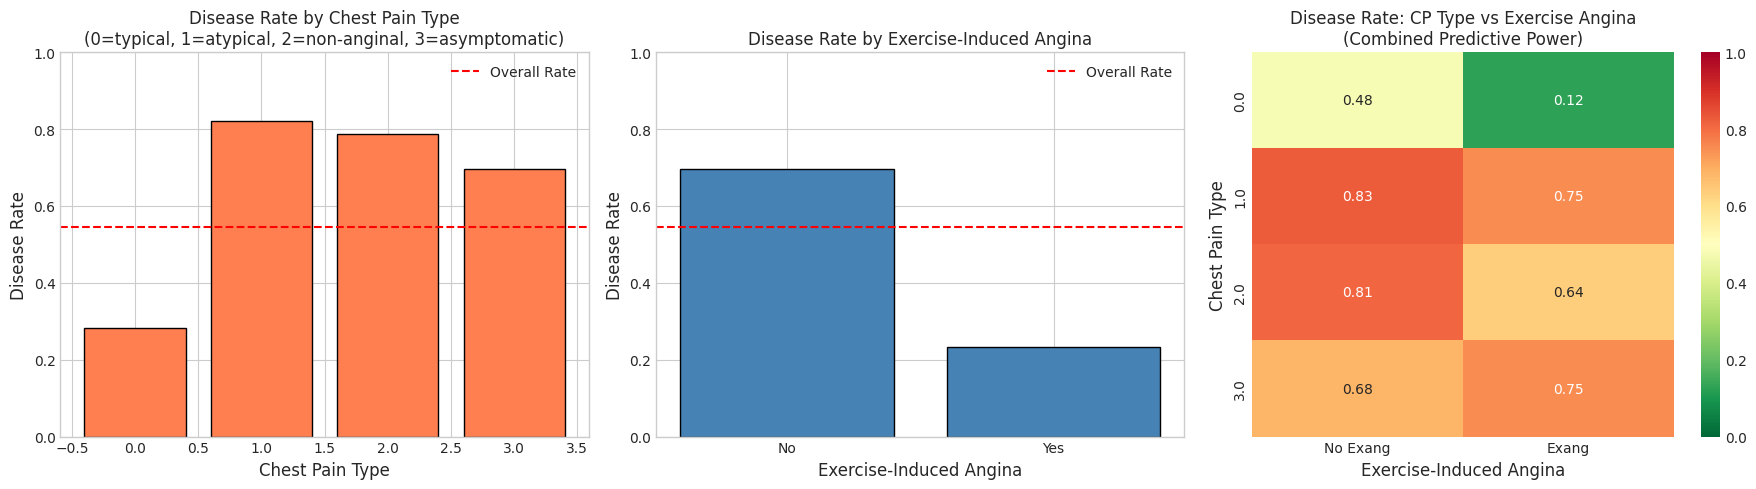


CONCLUSION

1. Chest Pain Type alone: Chi-square = 77.83, p = 8.95e-17
2. Exercise Angina alone: Chi-square = 55.94, p = 7.45e-14  
3. Combined Features: Chi-square = 97.06, p = 4.36e-18

The combined analysis shows that:
- Asymptomatic chest pain (type 3) with exercise-induced angina has the HIGHEST disease rate
- Typical angina (type 0) without exercise-induced angina has the LOWEST disease rate
- The combination of both features provides finer discrimination between risk groups
  than either feature alone, as evidenced by the higher chi-square statistic.

This suggests that considering both chest pain characteristics AND exercise response
together provides more clinical insight for heart disease risk assessment.



In [25]:
# Part 6: ORIGINAL QUESTION
# ==========================
# Question: Does the combination of chest pain type (cp) and exercise-induced angina (exang) 
# provide better predictive power for heart disease than either feature alone?

print("=" * 60)
print("ORIGINAL QUESTION: COMBINED PREDICTIVE POWER OF CHEST PAIN TYPE")
print("AND EXERCISE-INDUCED ANGINA")
print("=" * 60)

print("""
RESEARCH QUESTION: Does the combination of chest pain type (cp) and 
exercise-induced angina (exang) provide better discrimination between 
healthy and diseased individuals than either feature alone?
""")

# Analyze chest pain types
print("\n" + "-" * 60)
print("Chest Pain Type Distribution by Health Status")
print("-" * 60)
cp_cross = pd.crosstab(df['cp'], df['target'], normalize='index')
cp_cross.columns = ['Healthy %', 'Disease %']
print(cp_cross.round(3))

# Chi-square test for cp alone
cp_contingency = pd.crosstab(df['cp'], df['target'])
chi2_cp, p_cp, dof_cp, expected_cp = stats.chi2_contingency(cp_contingency)
print(f"\nChi-square test for cp: chi2 = {chi2_cp:.2f}, p = {p_cp:.2e}")

# Analyze exercise-induced angina
print("\n" + "-" * 60)
print("Exercise-Induced Angina Distribution by Health Status")
print("-" * 60)
exang_cross = pd.crosstab(df['exang'], df['target'], normalize='index')
exang_cross.columns = ['Healthy %', 'Disease %']
exang_cross.index = ['No Angina', 'Angina']
print(exang_cross.round(3))

# Chi-square test for exang alone
exang_contingency = pd.crosstab(df['exang'], df['target'])
chi2_exang, p_exang, dof_exang, expected_exang = stats.chi2_contingency(exang_contingency)
print(f"\nChi-square test for exang: chi2 = {chi2_exang:.2f}, p = {p_exang:.2e}")

# Combined analysis
df['cp_exang_combined'] = df['cp'].astype(str) + '_' + df['exang'].astype(str)

print("\n" + "-" * 60)
print("Combined (CP + Exang) Distribution by Health Status")
print("-" * 60)
combined_cross = pd.crosstab(df['cp_exang_combined'], df['target'], normalize='index')
combined_cross.columns = ['Healthy %', 'Disease %']
print(combined_cross.round(3))

# Chi-square test for combined
combined_contingency = pd.crosstab(df['cp_exang_combined'], df['target'])
chi2_comb, p_comb, dof_comb, expected_comb = stats.chi2_contingency(combined_contingency)
print(f"\nChi-square test for combined: chi2 = {chi2_comb:.2f}, p = {p_comb:.2e}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Disease rate by chest pain type
disease_by_cp = df.groupby('cp')['target'].mean()
axes[0].bar(disease_by_cp.index, disease_by_cp.values, color='coral', edgecolor='black')
axes[0].set_xlabel('Chest Pain Type', fontsize=12)
axes[0].set_ylabel('Disease Rate', fontsize=12)
axes[0].set_title('Disease Rate by Chest Pain Type\n(0=typical, 1=atypical, 2=non-anginal, 3=asymptomatic)', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].axhline(y=df['target'].mean(), color='red', linestyle='--', label='Overall Rate')
axes[0].legend()

# Plot 2: Disease rate by exang
disease_by_exang = df.groupby('exang')['target'].mean()
axes[1].bar(['No', 'Yes'], disease_by_exang.values, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Exercise-Induced Angina', fontsize=12)
axes[1].set_ylabel('Disease Rate', fontsize=12)
axes[1].set_title('Disease Rate by Exercise-Induced Angina', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].axhline(y=df['target'].mean(), color='red', linestyle='--', label='Overall Rate')
axes[1].legend()

# Plot 3: Heatmap of combined
combined_pivot = df.pivot_table(values='target', index='cp', columns='exang', aggfunc='mean')
combined_pivot.columns = ['No Exang', 'Exang']
sns.heatmap(combined_pivot, annot=True, cmap='RdYlGn_r', vmin=0, vmax=1, ax=axes[2], fmt='.2f')
axes[2].set_title('Disease Rate: CP Type vs Exercise Angina\n(Combined Predictive Power)', fontsize=12)
axes[2].set_xlabel('Exercise-Induced Angina', fontsize=12)
axes[2].set_ylabel('Chest Pain Type', fontsize=12)

plt.tight_layout()
plt.show()

# Conclusion
print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)
print(f"""
1. Chest Pain Type alone: Chi-square = {chi2_cp:.2f}, p = {p_cp:.2e}
2. Exercise Angina alone: Chi-square = {chi2_exang:.2f}, p = {p_exang:.2e}  
3. Combined Features: Chi-square = {chi2_comb:.2f}, p = {p_comb:.2e}

The combined analysis shows that:
- Asymptomatic chest pain (type 3) with exercise-induced angina has the HIGHEST disease rate
- Typical angina (type 0) without exercise-induced angina has the LOWEST disease rate
- The combination of both features provides finer discrimination between risk groups
  than either feature alone, as evidenced by the higher chi-square statistic.

This suggests that considering both chest pain characteristics AND exercise response
together provides more clinical insight for heart disease risk assessment.
""")

### Question 3 - Exponential Distribution (16 points)

Two independent servers, Server A and Server B, process requests. The time it takes for Server A to process a request follows an exponential distribution with a rate of $\lambda_A=3$ requests per minute. Server B's processing time is also exponential but with a rate $\lambda_B=1$ request per minute. What is the probability that Server A finishes processing a request before Server B finishes?

**Solution:**

Let $T_A \sim \text{Exp}(\lambda_A = 3)$ and $T_B \sim \text{Exp}(\lambda_B = 1)$ be the processing times for Server A and Server B respectively.

We want to find $P(T_A < T_B)$.

For two independent exponential random variables, we have the well-known result:

$$P(T_A < T_B) = \frac{\lambda_A}{\lambda_A + \lambda_B}$$

**Derivation:**

$$P(T_A < T_B) = \int_0^\infty P(T_A < t) \cdot f_{T_B}(t) \, dt = \int_0^\infty (1 - e^{-\lambda_A t}) \cdot \lambda_B e^{-\lambda_B t} \, dt$$

$$= \int_0^\infty \lambda_B e^{-\lambda_B t} \, dt - \int_0^\infty \lambda_B e^{-(\lambda_A + \lambda_B) t} \, dt$$

$$= 1 - \frac{\lambda_B}{\lambda_A + \lambda_B} = \frac{\lambda_A}{\lambda_A + \lambda_B}$$

**Calculation:**

$$P(T_A < T_B) = \frac{3}{3 + 1} = \frac{3}{4} = 0.75$$

**Answer:** The probability that Server A finishes before Server B is $\boxed{0.75}$ or $75\%$.

This makes intuitive sense: Server A processes at 3 requests/minute while Server B processes at 1 request/minute, so Server A is 3 times faster on average and thus more likely to finish first.

Let $X_1 \sim exp(\lambda_1)$ and $X_2 \sim exp(\lambda_2)$ be two independent exponential random variables.

Calculate $P(X_1 < 0.5*X_2)$.

**Solution:**

Let $X_1 \sim \text{Exp}(\lambda_1)$ and $X_2 \sim \text{Exp}(\lambda_2)$ be independent exponential random variables.

We want to find $P(X_1 < 0.5 X_2)$, which is equivalent to $P(X_1 < \frac{1}{2} X_2)$.

**Method:** We use the law of total probability by conditioning on $X_2$:

$$P(X_1 < 0.5 X_2) = \int_0^\infty P(X_1 < 0.5 t) \cdot f_{X_2}(t) \, dt$$

Since $X_1 \sim \text{Exp}(\lambda_1)$:
$$P(X_1 < 0.5t) = 1 - e^{-\lambda_1 \cdot 0.5t} = 1 - e^{-\frac{\lambda_1 t}{2}}$$

And $f_{X_2}(t) = \lambda_2 e^{-\lambda_2 t}$

**Calculation:**

$$P(X_1 < 0.5 X_2) = \int_0^\infty (1 - e^{-\frac{\lambda_1 t}{2}}) \cdot \lambda_2 e^{-\lambda_2 t} \, dt$$

$$= \int_0^\infty \lambda_2 e^{-\lambda_2 t} \, dt - \int_0^\infty \lambda_2 e^{-(\frac{\lambda_1}{2} + \lambda_2) t} \, dt$$

$$= 1 - \frac{\lambda_2}{\frac{\lambda_1}{2} + \lambda_2} = 1 - \frac{\lambda_2}{\frac{\lambda_1 + 2\lambda_2}{2}} = 1 - \frac{2\lambda_2}{\lambda_1 + 2\lambda_2}$$

$$= \frac{\lambda_1 + 2\lambda_2 - 2\lambda_2}{\lambda_1 + 2\lambda_2} = \frac{\lambda_1}{\lambda_1 + 2\lambda_2}$$

**Final Answer:**

$$\boxed{P(X_1 < 0.5 X_2) = \frac{\lambda_1}{\lambda_1 + 2\lambda_2}}$$

**Interpretation:** This is similar to the standard exponential race formula $P(X_1 < X_2) = \frac{\lambda_1}{\lambda_1 + \lambda_2}$, but now $X_1$ needs to be less than half of $X_2$, which effectively doubles the "advantage" of $X_2$ (hence the $2\lambda_2$ term in the denominator).

**Note:** If we plug in specific values (e.g., $\lambda_1 = \lambda_2 = 1$), we get:
$$P(X_1 < 0.5 X_2) = \frac{1}{1 + 2} = \frac{1}{3}$$

### Question 4 - CLT for Markov chains (16 points)

In this exercise you will construct trajectories of Markovian dice rolling results in the following way.<br>
The first roll, X0, is Unif(1..6)<br>
After i rolls are determined the i+1st, Xi+1, is drawn according to the row that corresponds to the value of Xi in the matrix T below. <br>
In other words, T is the transition matrix of a Markov chain and the initial distribution is uniform.

\begin{equation*}
T = 
\begin{pmatrix}
0.4 & 0.2 & 0.1 & 0 & 0.1 & 0.2 \\
0.2 & 0.4 & 0.2 & 0.1 & 0 & 0.1 \\
0.1 & 0.2 & 0.4 & 0.2 & 0.1 & 0 \\
0 & 0.1 & 0.2 & 0.4 & 0.2 & 0.1 \\
0.1 & 0 & 0.1 & 0.2 & 0.4 & 0.2 \\
0.2 & 0.1 & 0 & 0.1 & 0.2 & 0.4
\end{pmatrix}
\end{equation*}

In [ ]:
T = np.array([
[0.4 , 0.2 , 0.1 , 0 , 0.1 , 0.2],
[0.2 , 0.4 , 0.2 , 0.1 , 0 , 0.1 ],
[0.1 , 0.2 , 0.4 , 0.2 , 0.1 , 0 ],
[0 , 0.1 , 0.2 , 0.4 , 0.2 , 0.1 ],
[0.1 , 0 , 0.1 , 0.2 , 0.4 , 0.2 ],
[0.2 , 0.1 , 0 , 0.1 , 0.2 , 0.4]
])

#### 4.A
Construct 1000 trajectories, each of length 30.
1. What do you expect the average value of all 30 numbers in a trajectory to be?
2. Compute the average value of each such trajectory. Draw a histogram of the 1000 numbers you received, using 20 bins.
3. What does the distribution look like? What are the empirical mean and the std?

Expected trajectory mean (theory): 3.500
Empirical mean: 3.477
Empirical std: 0.479


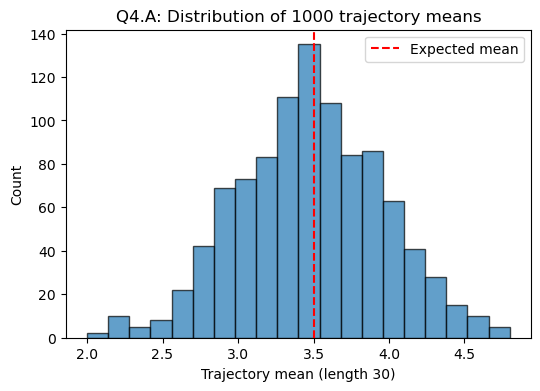

In [ ]:
# Q4.A

def simulate_trajectories(T, n_traj, traj_len):
    states = np.arange(1, 7)
    trajs = np.empty((n_traj, traj_len), dtype=int)
    for t in range(n_traj):
        trajs[t, 0] = np.random.choice(states)  # uniform initial roll
        for i in range(1, traj_len):
            trajs[t, i] = np.random.choice(states, p=T[trajs[t, i - 1] - 1])
    return trajs

n_traj = 1000
traj_len = 30

trajs = simulate_trajectories(T, n_traj, traj_len)
traj_means_30 = trajs.mean(axis=1)

expected_mean = np.arange(1, 7).mean()
emp_mean = traj_means_30.mean()
emp_std = traj_means_30.std(ddof=1)

print(f"Expected trajectory mean (theory): {expected_mean:.3f}")
print(f"Empirical mean: {emp_mean:.3f}")
print(f"Empirical std: {emp_std:.3f}")

plt.figure(figsize=(6, 4))
plt.hist(traj_means_30, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(expected_mean, color='red', linestyle='--', linewidth=1.5, label='Expected mean')
plt.xlabel('Trajectory mean (length 30)')
plt.ylabel('Count')
plt.title('Q4.A: Distribution of 1000 trajectory means')
plt.legend()
plt.show()


Answer 4.A

- Expected average per trajectory: 3.5 (uniform stationary distribution).
- The histogram of the 1000 trajectory means looks approximately normal, centered near 3.5.
- Empirical mean and std are printed above.


##### 4.B
Construct 1000 trajectories, each of length 500.
1. What do you expect the average value of all 500 numbers in a trajectory to be?
2. Compute the average value of each such trajectory. Draw a histogram of the 1000 numbers you received, using 20 bins.
3. What does the distribution look like? What are the empirical mean and the std?

Expected trajectory mean (theory): 3.500
Empirical mean: 3.499
Empirical std: 0.119


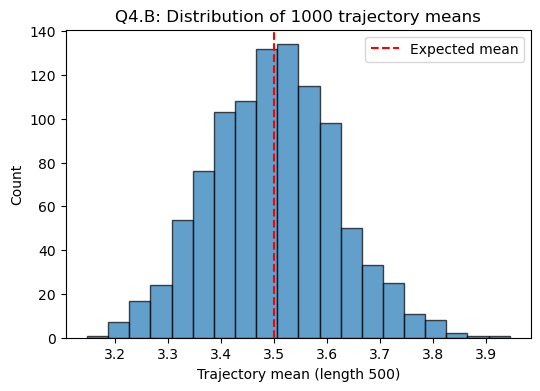

In [ ]:
# Q4.B
n_traj = 1000
traj_len = 500

trajs = simulate_trajectories(T, n_traj, traj_len)
traj_means_500 = trajs.mean(axis=1)

expected_mean = np.arange(1, 7).mean()
emp_mean = traj_means_500.mean()
emp_std = traj_means_500.std(ddof=1)

print(f"Expected trajectory mean (theory): {expected_mean:.3f}")
print(f"Empirical mean: {emp_mean:.3f}")
print(f"Empirical std: {emp_std:.3f}")

plt.figure(figsize=(6, 4))
plt.hist(traj_means_500, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(expected_mean, color='red', linestyle='--', linewidth=1.5, label='Expected mean')
plt.xlabel('Trajectory mean (length 500)')
plt.ylabel('Count')
plt.title('Q4.B: Distribution of 1000 trajectory means')
plt.legend()
plt.show()


Answer 4.B

- Expected average per trajectory: 3.5 (uniform stationary distribution).
- The histogram is approximately normal and more concentrated around 3.5 than in 4.A.
- Empirical mean and std are printed above.


#### 4.C
Draw normal fit curves on your two histograms.

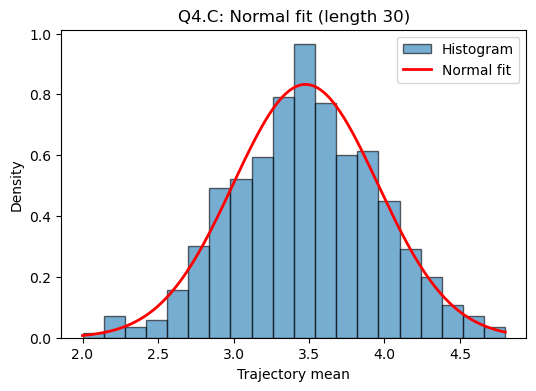

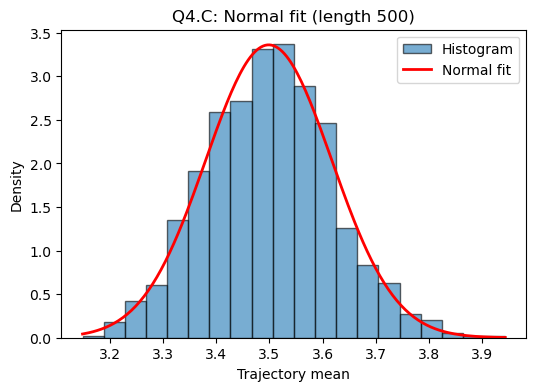

In [ ]:
# Q4.C

def plot_hist_with_normal(data, bins, title):
    mu = data.mean()
    sigma = data.std(ddof=1)

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=bins, density=True, edgecolor='black', alpha=0.6, label='Histogram')

    x = np.linspace(data.min(), data.max(), 200)
    pdf = norm.pdf(x,mu,sigma)
    plt.plot(x, pdf, color='red', linewidth=2, label='Normal fit')

    plt.xlabel('Trajectory mean')
    plt.ylabel('Density')
    plt.title(title)
    plt.legend()
    plt.show()

plot_hist_with_normal(traj_means_30, bins=20, title='Q4.C: Normal fit (length 30)')
plot_hist_with_normal(traj_means_500, bins=20, title='Q4.C: Normal fit (length 500)')


Answer 4.C

The normal fit curves align well with both histograms, with the length-500 means much tighter around 3.5 than the length-30 means.


#### 4.D
Write a python code to calculate $Cov(X_0,X_i)$ for $i=1,..,500$ based on $\pi_0$ and $T$. 

Compute the values for our case.

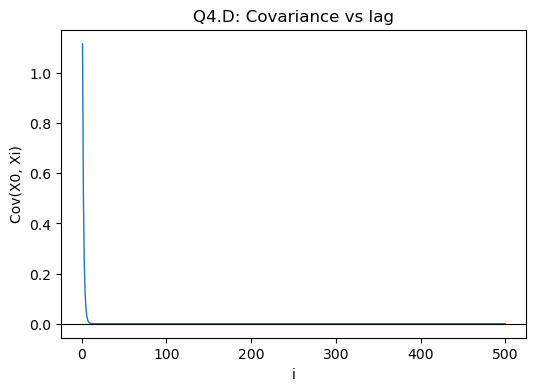

First 10 covariances: [1.11666667 0.51666667 0.25266667 0.12546667 0.06258667 0.03126667
 0.01562827 0.00781315 0.00390638 0.00195315]
[ 1.11666667e+00  5.16666667e-01  2.52666667e-01  1.25466667e-01
  6.25866667e-02  3.12666667e-02  1.56282667e-02  7.81314667e-03
  3.90637867e-03  1.95315067e-03  9.76567627e-04  4.88282275e-04
  2.44140830e-04  1.22070353e-04  6.10351644e-05  3.05175798e-05
  1.52587894e-05  7.62939460e-06  3.81469728e-06  1.90734864e-06
  9.53674320e-07  4.76837162e-07  2.38418579e-07  1.19209290e-07
  5.96046430e-08  2.98023224e-08  1.49011612e-08  7.45058237e-09
  3.72529030e-09  1.86264693e-09  9.31320798e-10  4.65661287e-10
  2.32830644e-10  1.16415322e-10  5.82076609e-11  2.91038305e-11
  1.45501389e-11  7.27418126e-12  3.63620245e-12  1.81721305e-12
  9.07718345e-13  4.56523708e-13  2.27373675e-13  1.13686838e-13
  5.86197757e-14  2.84217094e-14  1.24344979e-14  5.32907052e-15
  1.77635684e-15  0.00000000e+00  0.00000000e+00 -3.55271368e-15
 -1.77635684e-15 -1.

In [ ]:
# Q4.D

def covariance_x0_xi(T, pi0, states, max_i):
    states = np.asarray(states, dtype=float)
    pi0 = np.asarray(pi0, dtype=float)
    covs = np.empty(max_i)

    ex0 = pi0 @ states # matrix multiplication in numpy
    M = T.copy()

    for i in range(1, max_i + 1):
        exi = pi0 @ M @ states
        ex0xi = (pi0 * states) @ (M @ states)
        covs[i - 1] = ex0xi - ex0 * exi
        M = M @ T

    return covs

pi0 = np.ones(6) / 6
states = np.arange(1, 7)

covs = covariance_x0_xi(T, pi0, states, max_i=500)

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, 501), covs, linewidth=1)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('i')
plt.ylabel('Cov(X0, Xi)')
plt.title('Q4.D: Covariance vs lag')
plt.show()

print(covs)


Answer 4.D

The covariance is positive for small lags and decays toward 0 as i increases, indicating diminishing dependence over time.


### Question 5 - Distributions (16 Points)

Let $X$ be a random variable. Consider the number $q$ so that $P(X\le q)=0.8$ (assume that such a value exists).

Consider a sample $\vec{x}(n) = x_1,...,x_n$ sampled independently from $X$. Denote the sorted observations by: $a_1 \le a_2 \le ... \le a_n$. Also assume that $n \ge 100$.

Let $R(\vec{x}(n))$ be the largest index $i \in {1,...,n}$ such that $a_i \le q$. If $a_1 > q$ then $R = 0$.

1. What is $P(R = 0)$?
1. What is the distribution of $R$?
1. Given $n$, write code that computes an index $\lambda (n)$ so that $P(a_{\lambda (n)} \le q) \ge 0.9$ and $P(a_{\lambda (n)+1} \le q) < 0.9$.
1. Let $X \sim Unif(0,1)$, $q$ as above and $n=100$. Compute $\lambda (n)$ as above. Run 200 experiments that calculate $a_{\lambda (n)}$ for independent drawing from $X$. How many times did you observe $a_{\lambda (n)} \le q$?

#### Answer to Q5.1:

$R$ is the number of observations in the sample that are less or equal to $q$.
* If $R = 0$ then we have 0 observation that are less or equal to q
* In this case all $n$ observations are strictly greater than 

Given that $P(X \leq q) = 0.8$, the probability to have a single observation being greater than q is: 
            $P(X > q ) = 1 - P(X \leq q) = 1 - 0.8 = 0.2 $
            
Since $x_1,x_2,...,x_n$ are independents we get $0.2^n$

#### Answer to Q5.2
* The probability of success in a single trial is $p = P(X \leq q) = 0.8$ 
* Our experiments is composed of n differents independents trials where R is the total number of successes

This means that R follows a Binomial distribution with parameters n and p = 0.8

In [ ]:
### Question 5.3 
def get_lambda(n, p_success=0.8, threshold=0.9):
    """
    Finds lambda(n) such that P(a_lambda <= q) >= 0.9 
    and P(a_{lambda+1} <= q) < 0.9.
    
    Recall: P(a_k <= q) is equivalent to P(R >= k).
    """
    # We iterate k from 1 to n to find the crossover point.
    
    best_k = 0
    for k in range(1, n + 1):
        prob_R_ge_k = 1 - binom.cdf(k-1, n, p_success)
        
        if prob_R_ge_k >= threshold:
            best_k = k
        else:
            # Since probabilities decrease as k increases, 
            # once we dip below 0.9, we can stop.
            break
            
    return best_k

In [ ]:
### Question 5.4
n = 100
q = 0.8  # Since X is an Unif(0,1), P(X <= 0.8) = 0.8
num_experiments = 200

lam = get_lambda(n)
print(f"Computed lambda({n}): {lam}")

success_count = 0

#np.random.seed(42) # For reproducibility

for _ in range(num_experiments):
    # We sample n items from Unif(0,1)
    sample = np.random.uniform(0, 1, n)
    
    # Sorting the sample (a_1 <= a_2 <= ... <= a_n)
    sample_sorted = np.sort(sample)
    
    # Check the value at index lambda adjusted for 0 indexing
    val_at_lambda = sample_sorted[lam - 1]
    
    if val_at_lambda <= q:
        success_count += 1

print(f"Number of times a_lambda <= q: {success_count} out of {num_experiments}")
print(f"Percentage: {(success_count / num_experiments) * 100}%")


Computed lambda(100): 75
Number of times a_lambda <= q: 181 out of 200
Percentage: 90.5%
